In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

In [3]:
heart_disease = fetch_ucirepo(id=45)

In [4]:
X = heart_disease.data.features
y = heart_disease.data.targets

print("Ознаки (features):")
print(X.head())
print("\n" + "="*50)
print("\nЦільова змінна (target):")
print(y.head())

Ознаки (features):
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


Цільова змінна (target):
   num
0    0
1    2
2    1
3    0
4    0


In [5]:
df = pd.concat([X, y], axis=1)

df.columns = [col.replace('(', '_').replace(')', '') for col in df.columns]

print("Повний датасет:")
print(df.head())

Повний датасет:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None


In [7]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


In [8]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   
std      0.994971   22.8750

In [9]:
print(f"Назва датасету: {heart_disease.metadata.name}")
print(f"Кількість записів: {heart_disease.metadata.num_instances}")
print(f"Кількість ознак: {heart_disease.metadata.num_features}")
print(f"Типи ознак: {heart_disease.metadata.feature_types}")
print(f"Є пропуски: {heart_disease.metadata.has_missing_values}")

Назва датасету: Heart Disease
Кількість записів: 303
Кількість ознак: 13
Типи ознак: ['Categorical', 'Integer', 'Real']
Є пропуски: yes


In [10]:
df_clean = df.copy()

df_clean['ca'] = df_clean['ca'].replace('?', np.nan)
df_clean['thal'] = df_clean['thal'].replace('?', np.nan)

df_clean['ca'] = pd.to_numeric(df_clean['ca'], errors='coerce')
df_clean['thal'] = pd.to_numeric(df_clean['thal'], errors='coerce')

print("Пропуски до очищення:")
print(df.isnull().sum())

print("\nПропуски після конвертації:")
print(df_clean.isnull().sum())

df_clean = df_clean.dropna()

print(f"\nРозмір після видалення пропусків: {df_clean.shape}")

Пропуски до очищення:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Пропуски після конвертації:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Розмір після видалення пропусків: (297, 14)


In [11]:
print(df_clean.dtypes)

df_clean['sex'] = df_clean['sex'].astype('category')
df_clean['cp'] = df_clean['cp'].astype('category')
df_clean['fbs'] = df_clean['fbs'].astype('category')
df_clean['restecg'] = df_clean['restecg'].astype('category')
df_clean['exang'] = df_clean['exang'].astype('category')
df_clean['slope'] = df_clean['slope'].astype('category')
df_clean['ca'] = df_clean['ca'].astype('category')
df_clean['thal'] = df_clean['thal'].astype('category')

print("\nТипи даних після конвертації:")
print(df_clean.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

Типи даних після конвертації:
age            int64
sex         category
cp          category
trestbps       int64
chol           int64
fbs         category
restecg     category
thalach        int64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
num            int64
dtype: object


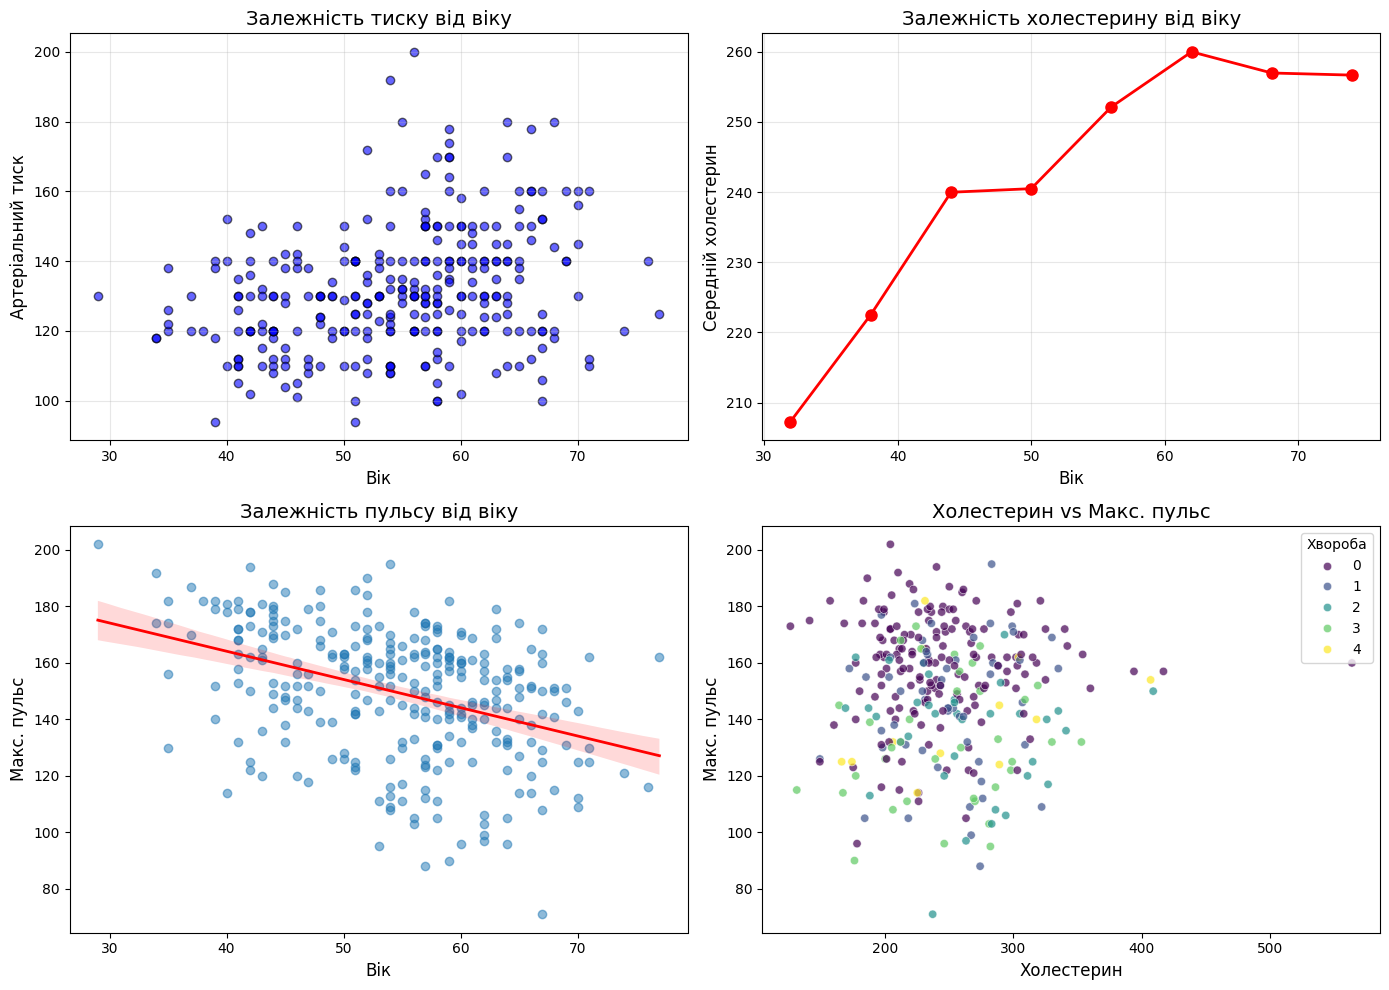

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(df_clean['age'], df_clean['trestbps'], alpha=0.6, c='blue', edgecolors='black')
axes[0, 0].set_xlabel('Вік', fontsize=12)
axes[0, 0].set_ylabel('Артеріальний тиск', fontsize=12)
axes[0, 0].set_title('Залежність тиску від віку', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)

age_groups = df_clean.groupby(pd.cut(df_clean['age'], bins=8))['chol'].mean().reset_index()
age_groups['age_mid'] = [interval.mid for interval in age_groups['age']]
axes[0, 1].plot(age_groups['age_mid'], age_groups['chol'], marker='o', linewidth=2, markersize=8, color='red')
axes[0, 1].set_xlabel('Вік', fontsize=12)
axes[0, 1].set_ylabel('Середній холестерин', fontsize=12)
axes[0, 1].set_title('Залежність холестерину від віку', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

sns.regplot(x='age', y='thalach', data=df_clean, ax=axes[1, 0], scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'linewidth':2})
axes[1, 0].set_xlabel('Вік', fontsize=12)
axes[1, 0].set_ylabel('Макс. пульс', fontsize=12)
axes[1, 0].set_title('Залежність пульсу від віку', fontsize=14)

sns.scatterplot(x='chol', y='thalach', hue='num', data=df_clean, ax=axes[1, 1], palette='viridis', alpha=0.7)
axes[1, 1].set_xlabel('Холестерин', fontsize=12)
axes[1, 1].set_ylabel('Макс. пульс', fontsize=12)
axes[1, 1].set_title('Холестерин vs Макс. пульс', fontsize=14)
axes[1, 1].legend(title='Хвороба')

plt.tight_layout()
plt.show()

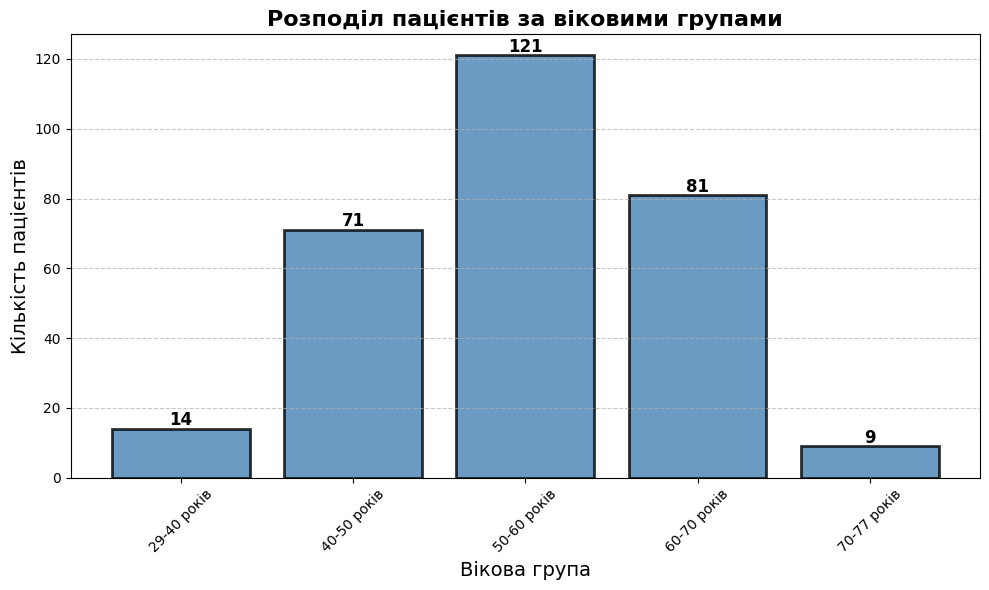

In [13]:
bins = [29, 40, 50, 60, 70, 77]
labels = ['29-40 років', '40-50 років', '50-60 років', '60-70 років', '70-77 років']

df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=False)

counts = df_clean['age_group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black', linewidth=2, alpha=0.8)
plt.title('Розподіл пацієнтів за віковими групами', fontsize=16, fontweight='bold')
plt.xlabel('Вікова група', fontsize=14)
plt.ylabel('Кількість пацієнтів', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(count), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

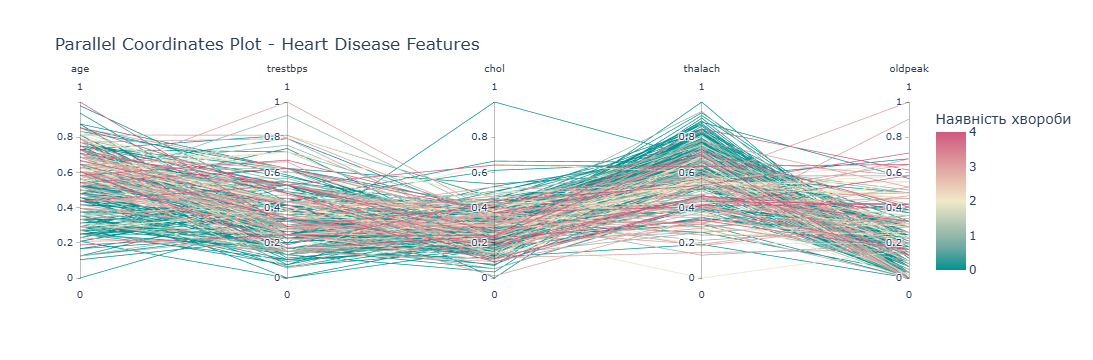

In [14]:
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_normalized = df_clean.copy()
scaler = MinMaxScaler()
df_normalized[num_cols] = scaler.fit_transform(df_clean[num_cols])

fig = px.parallel_coordinates(df_normalized, color='num', 
                              dimensions=num_cols + ['cp', 'thal', 'slope', 'ca'],
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              title='Parallel Coordinates Plot - Heart Disease Features',
                              labels={'num': 'Наявність хвороби'})
fig.show()

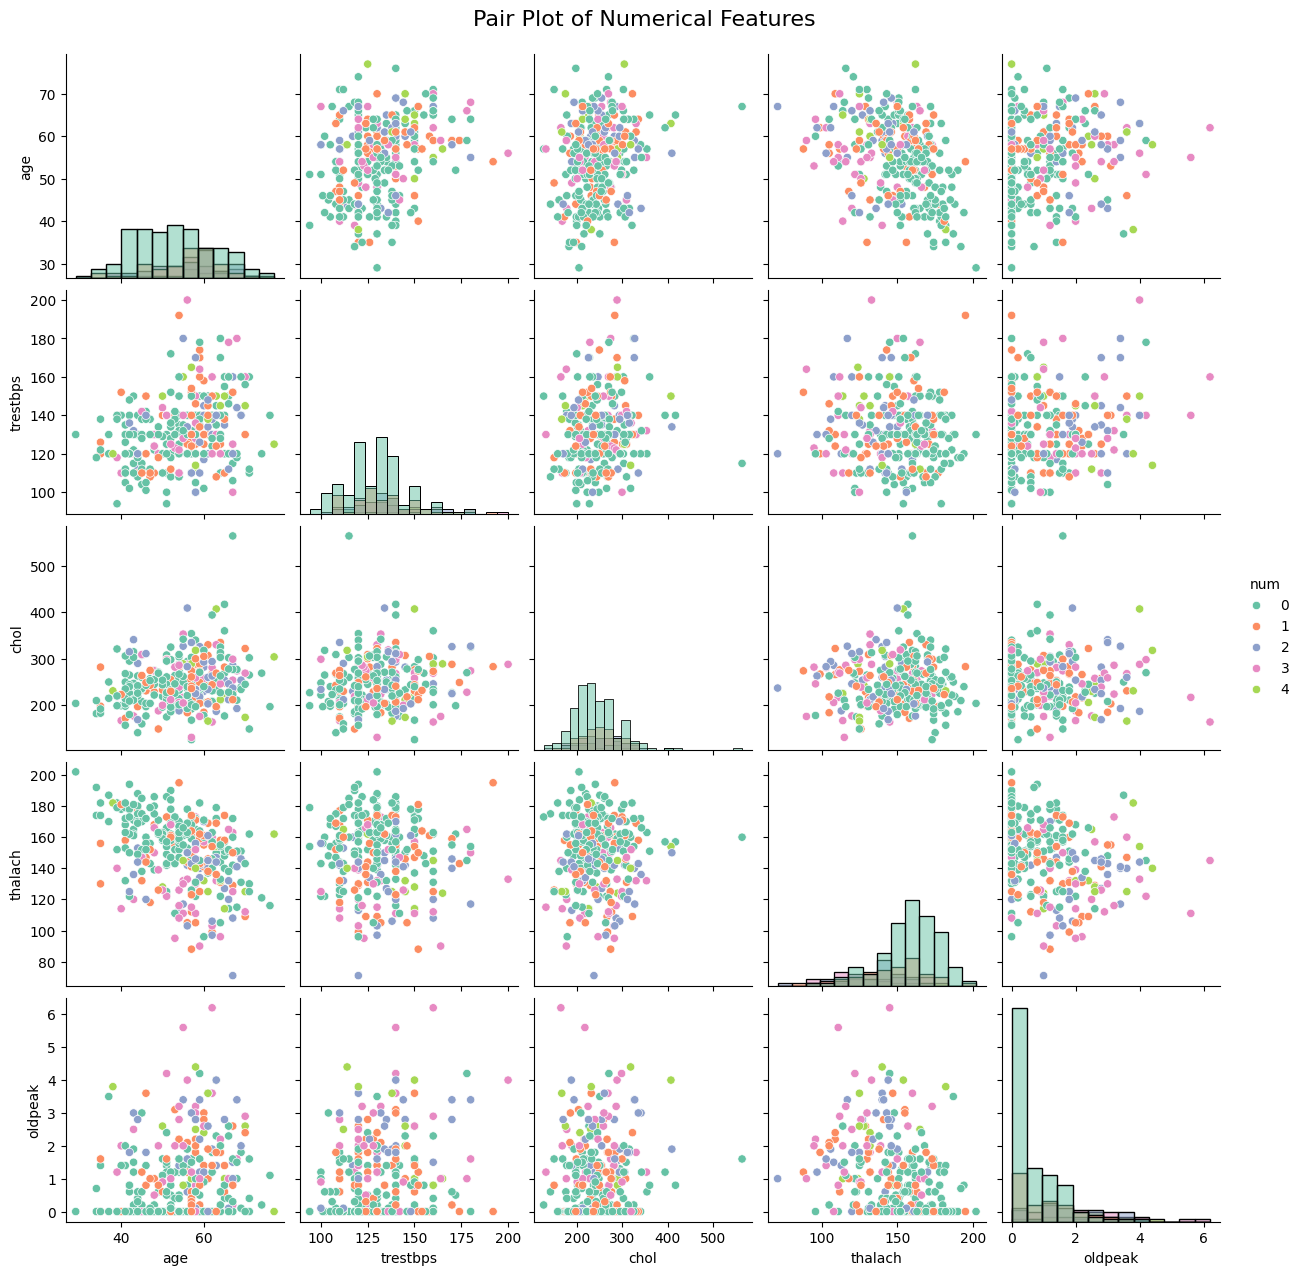

In [15]:
sns.pairplot(df_clean[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'num']], 
             hue='num', diag_kind='hist', palette='Set2', height=2.5)
plt.suptitle('Pair Plot of Numerical Features', y=1.02, fontsize=16)
plt.show()

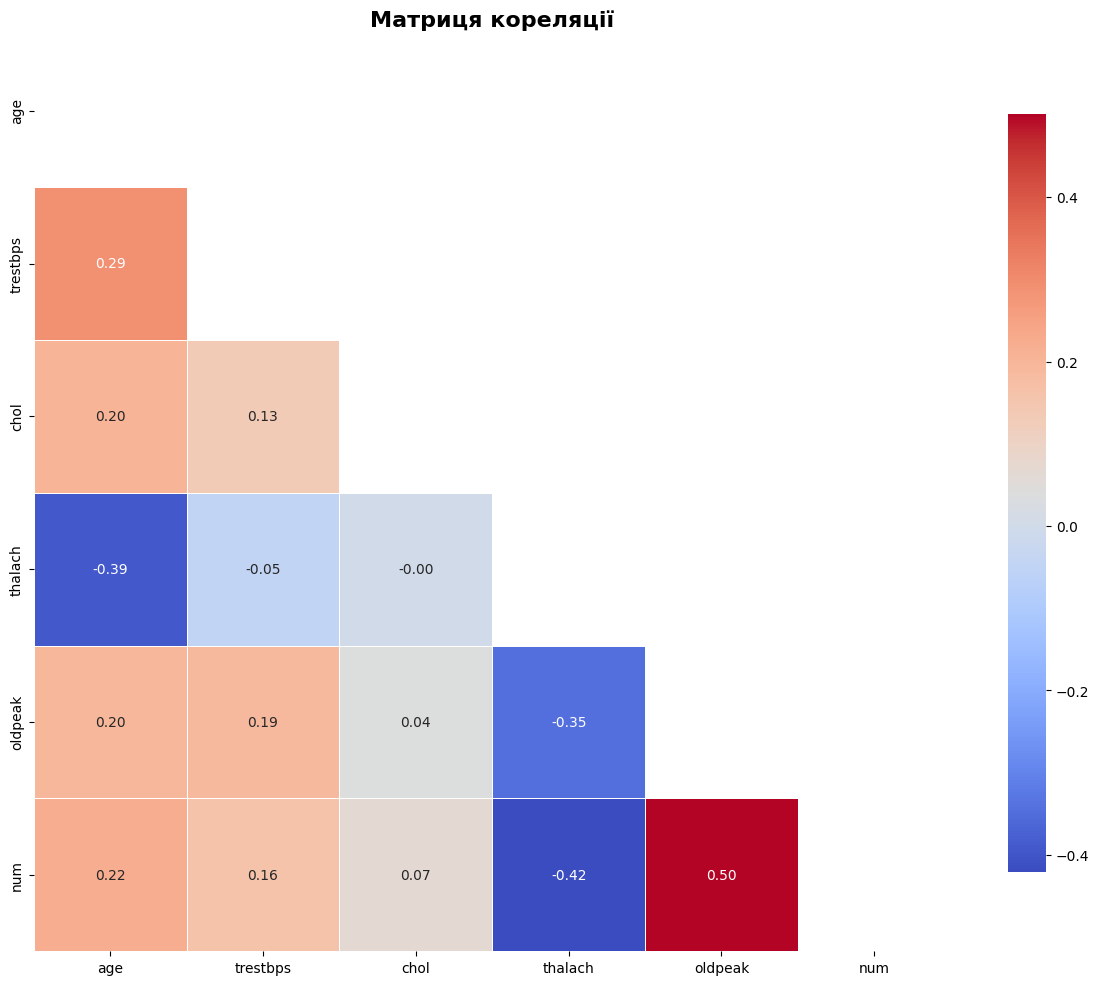

In [17]:
plt.figure(figsize=(12, 10))
corr = df_clean.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Матриця кореляції', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

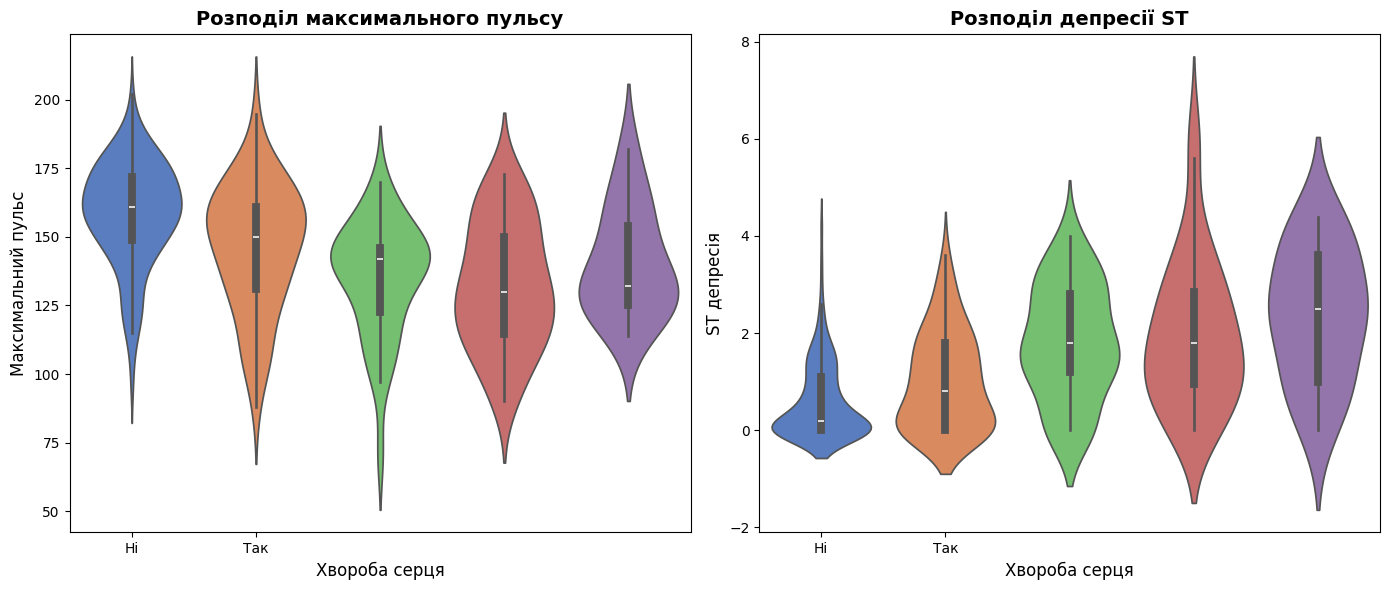

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df_clean, x='num', y='thalach', ax=axes[0], hue='num', palette='muted', legend=False)
axes[0].set_title('Розподіл максимального пульсу', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Хвороба серця', fontsize=12)
axes[0].set_ylabel('Максимальний пульс', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Ні', 'Так'])

sns.violinplot(data=df_clean, x='num', y='oldpeak', ax=axes[1], hue='num', palette='muted', legend=False)
axes[1].set_title('Розподіл депресії ST', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Хвороба серця', fontsize=12)
axes[1].set_ylabel('ST депресія', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Ні', 'Так'])

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

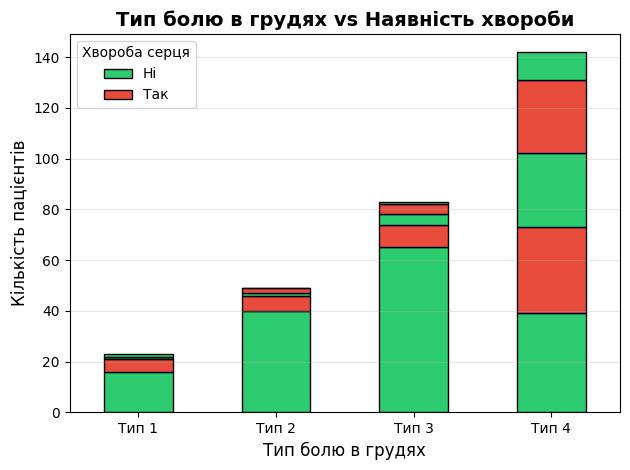

In [23]:
plt.figure(figsize=(10, 6))
cp_counts = df_clean.groupby(['cp', 'num']).size().unstack()
cp_counts.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Тип болю в грудях vs Наявність хвороби', fontsize=14, fontweight='bold')
plt.xlabel('Тип болю в грудях', fontsize=12)
plt.ylabel('Кількість пацієнтів', fontsize=12)
plt.xticks(ticks=range(4), labels=['Тип 1', 'Тип 2', 'Тип 3', 'Тип 4'], rotation=0)
plt.legend(['Ні', 'Так'], title='Хвороба серця')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

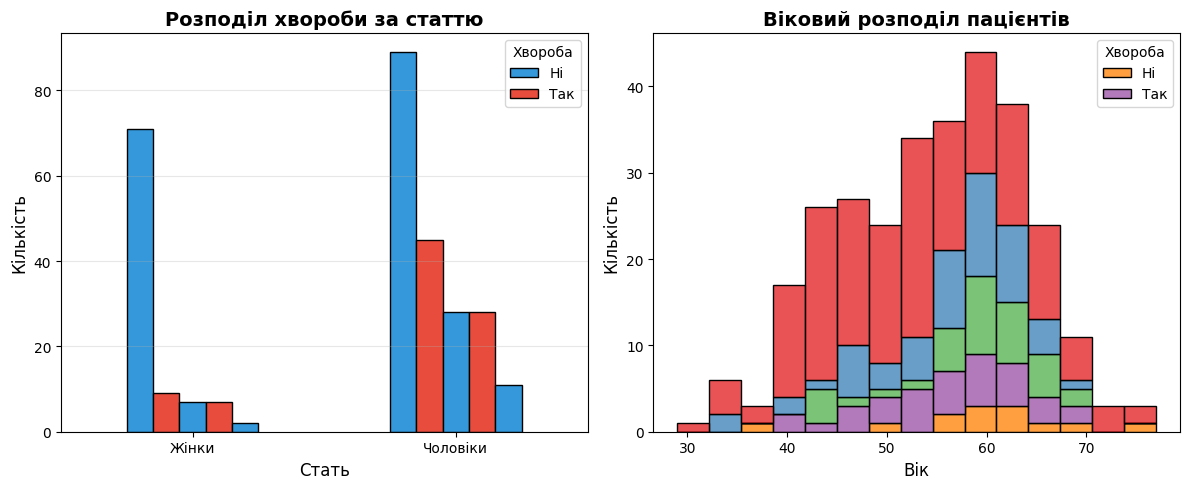

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sex_counts = df_clean.groupby(['sex', 'num']).size().unstack()
sex_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Розподіл хвороби за статтю', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Стать', fontsize=12)
axes[0].set_ylabel('Кількість', fontsize=12)
axes[0].set_xticklabels(['Жінки', 'Чоловіки'], rotation=0)
axes[0].legend(['Ні', 'Так'], title='Хвороба')
axes[0].grid(axis='y', alpha=0.3)

sns.histplot(data=df_clean, x='age', hue='num', bins=15, multiple='stack', ax=axes[1], palette='Set1')
axes[1].set_title('Віковий розподіл пацієнтів', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Вік', fontsize=12)
axes[1].set_ylabel('Кількість', fontsize=12)
axes[1].legend(['Ні', 'Так'], title='Хвороба')

plt.tight_layout()
plt.show()

In [21]:
df_clean.to_csv('heart_disease_cleaned.csv', index=False)
print("Датасет збережено як 'heart_disease_cleaned.csv'")

Датасет збережено як 'heart_disease_cleaned.csv'
